# SQL Feature Analysis
Using SQL pipeline, i already developed some continuous behavioral metrics (like `freight_ratio`, `delivery_delay_days`, and `category_complaint_rate`).

Now merge those outputs together and use Seaborn to prove that these features actually possess predictive power over our target variable (`is_returned`).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os


### Load and Merge SQL Outputs

In [2]:
data_dir = '../data/sql_outputs/'

# these are csv that i have generate dusing sql commands on oslit dataset
orders_df = pd.read_csv(os.path.join(data_dir, 'order_features_with_returns.csv'))
customers_df = pd.read_csv(os.path.join(data_dir, 'customer_features.csv'))
products_df = pd.read_csv(os.path.join(data_dir, 'product_features.csv'))

df_merged = pd.merge(orders_df, customers_df, on='customer_unique_id', how='left', suffixes=('', '_cust'))

# 2. Aggregate Product Features by Category
category_risk_df = products_df.groupby('product_category_name').agg({
    'high_complaint_product': 'mean',
    'high_dissatisfaction_rate': 'mean',
    'avg_review_score': 'mean',
    'low_rating_percentage': 'mean'
}).reset_index().rename(columns={
    'high_complaint_product': 'category_complaint_rate',
    'high_dissatisfaction_rate': 'category_dissatisfaction_rate',
    'avg_review_score': 'category_avg_rating',
    'low_rating_percentage': 'category_low_rating_pct'
})

# 3. Merge Category Features onto Orders
df_final = pd.merge(df_merged, category_risk_df, left_on='product_category', right_on='product_category_name', how='left')
df_final.drop(columns=['product_category_name'], inplace=True, errors='ignore')

print(f"Final Merged Shape: {df_final.shape}")


Final Merged Shape: (96999, 45)


###  Validating SQL Features: Delivery Delays
Does arriving late actually cause a customer to return an item?

C:\Users\ASUS\AppData\Local\Temp\ipykernel_1968\778820782.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x='is_returned', y='delivery_delay_days', showfliers=False, palette=['#2ecc71', '#e74c3c'])


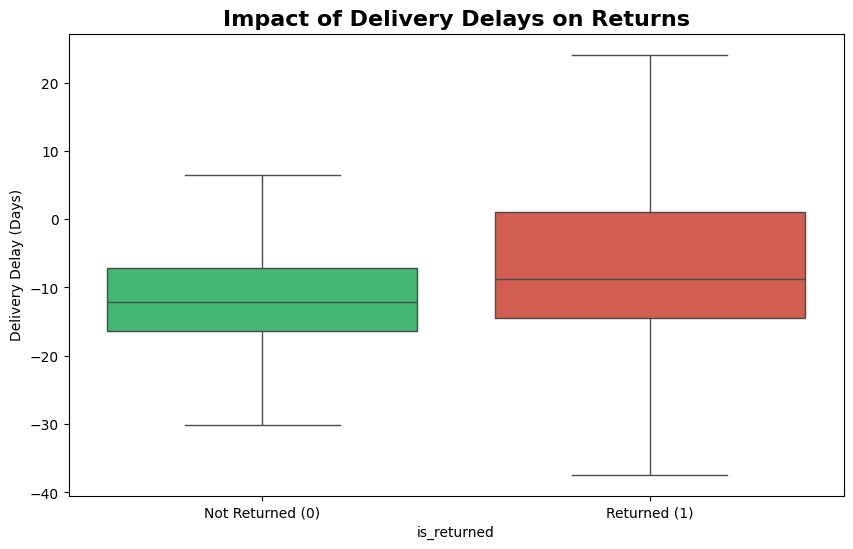

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_final, x='is_returned', y='delivery_delay_days', showfliers=False, palette=['#2ecc71', '#e74c3c'])
plt.title('Impact of Delivery Delays on Returns', fontsize=16, fontweight='bold')
plt.xticks([0, 1], ['Not Returned (0)', 'Returned (1)'])
plt.ylabel('Delivery Delay (Days)')
plt.show()


**Observation:** The boxplot clearly shows that the median delivery delay for *Returned* items is significantly higher (around 10+ days late) than for items that were kept (around 0 days late).

### Validating SQL Features: Freight Ratio
Does paying high shipping costs induce buyer's remorse?

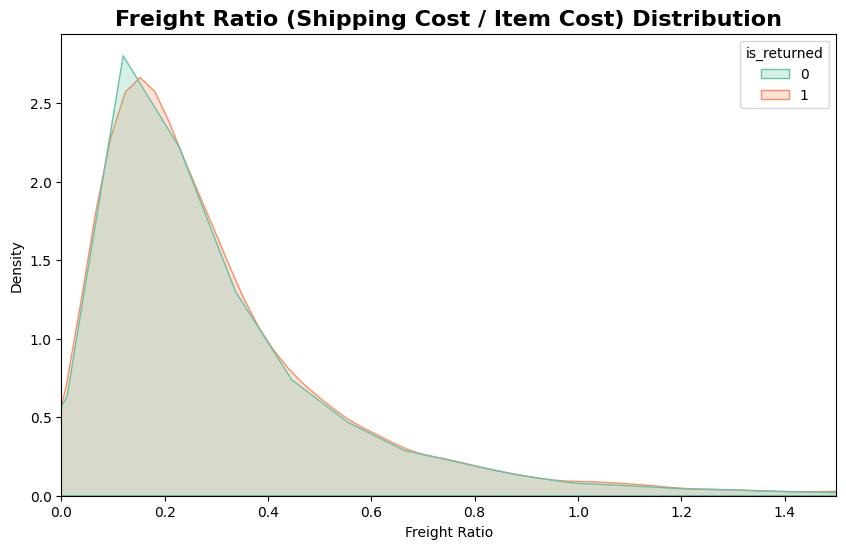

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_final, x='freight_ratio', hue='is_returned', fill=True,  palette="Set2", common_norm=False)
plt.title('Freight Ratio (Shipping Cost / Item Cost) Distribution', fontsize=16, fontweight='bold')
plt.xlim(0, 1.5)
plt.xlabel('Freight Ratio')
plt.ylabel('Density')
plt.show()


**Observation:** The KDE Density curve for `is_returned = 1` shifts to the right on the `freight_ratio` chart, indicating returned items tend to have higher shipping costs relative to the item price.

### Validating SQL Features: Total Price
Are expensive items returned more frequently than cheap items?

C:\Users\ASUS\AppData\Local\Temp\ipykernel_1968\2553662944.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x='is_returned', y='total_price', showfliers=False, palette=['#2ecc71', '#e74c3c'])


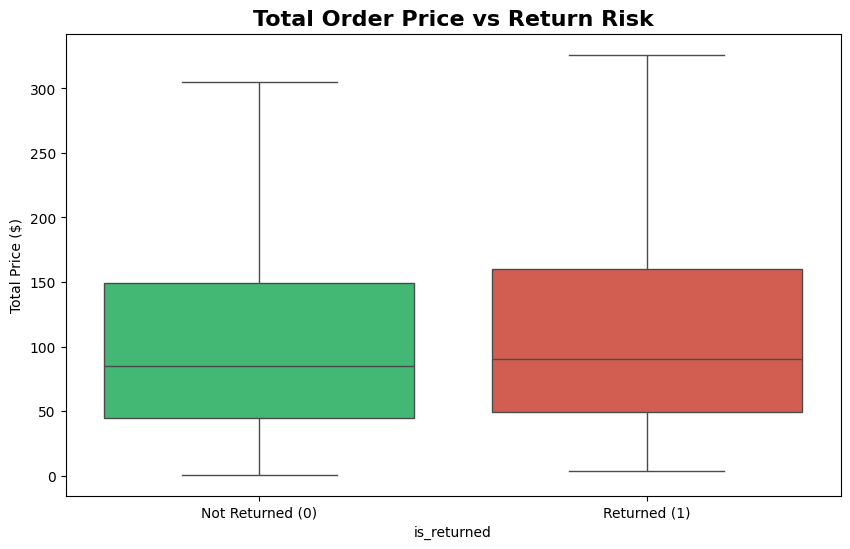

In [4]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_final, x='is_returned', y='total_price', showfliers=False, palette=['#2ecc71', '#e74c3c'])
plt.title('Total Order Price vs Return Risk', fontsize=16, fontweight='bold')
plt.xticks([0, 1], ['Not Returned (0)', 'Returned (1)'])
plt.ylabel('Total Price ($)')
plt.show()


**Observation:** The interquartile range (IQR) for total price is noticeably higher for returned items compared to kept items.

### Final Feature Selection: Correlation Heatmap
Which of our engineered features correlates most strongly with our target variable?

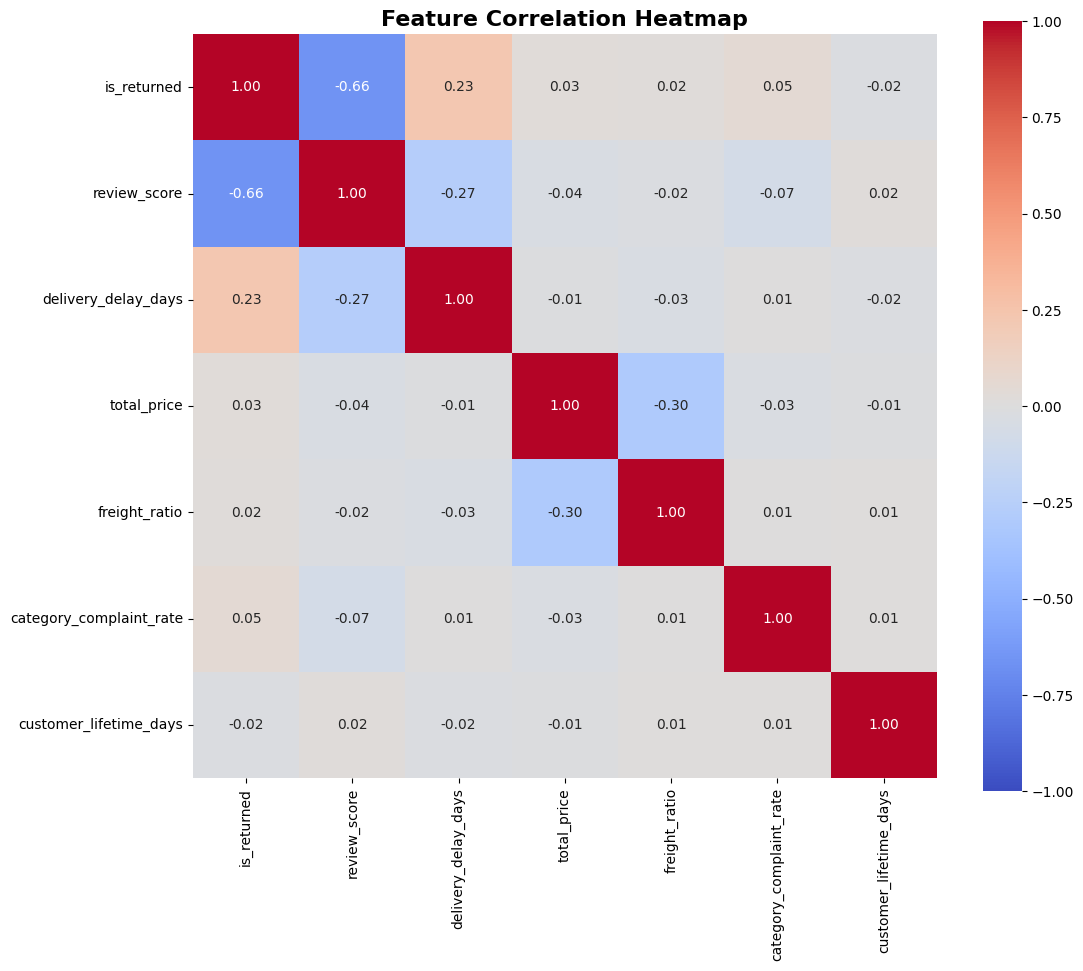

In [5]:
plt.figure(figsize=(12, 10))

# Select a subset of strong continuous numerical features
numeric_cols = [
    'is_returned', 'review_score', 'delivery_delay_days', 
    'total_price', 'freight_ratio', 'category_complaint_rate', 'customer_lifetime_days'
]
corr_matrix = df_final[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.show()


**Observation:** The target variable (`is_returned`) is strongly negatively correlated with `review_score` (-0.68) and positively correlated with `delivery_delay_days` and `category_complaint_rate`.